# **General Analyses of the Network**

In [4]:
import pandas as pd
import numpy as np
import networkx as nx

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
edges = pd.read_csv("../data/edges.csv")[["# source", " target", " distance"]].drop_duplicates()

nodes = pd.read_csv("../data/nodes.csv")[[" id", " name", " city", " country"]]
nodes[" id"] = np.arange(0, 3214)

In [5]:
source_airport = np.array(edges["# source"])
destination_airport = np.array(edges[" target"])

In [12]:
edges

,# source,target,distance
0,0,2,124.520121
1,0,3,157.150822
2,0,1,106.747399
3,0,4,424.726096
5,1,0,106.747399
...,...,...,...
66764,3211,1655,731.349310
66765,3211,2840,375.021414
66766,3211,2767,1217.384762
66769,3212,1675,425.533589


In [47]:
A = np.array([[0 for i in range(3214)] for i in range(3214)])

assert len(source_airport) == len(destination_airport)

for source, target, distance in edges.values:
    A[np.int16(source)][np.int16(target)] = distance


In [48]:
# nx representation (10 seconds)

G = nx.from_numpy_array(A) # Undirected!

# **Hustota siete**

In [89]:
len(edges)/3214**2

0.0035728682347647522

In [ ]:
nx.density(G)
# Dosť nízka, niečo nad 0.3 %
# Koniec koncov, napriamo sa vieme dostať iba do cca 0.35 % dvojíc
# Dosť podobné čísla, má to spojitosť?

0.0036523217459562126

# **Počet komponent súvislosti**

In [55]:
nx.number_connected_components(G)

7

In [ ]:
for component in nx.connected_components(G):
    #print(100*len(component)/3214)
    print(component)

# ale je tu komponent, ktorý tvorí 99.19 % !!!

# Tieto malé:

# {931, 932, 933, 934, 935, 936, 937, 2535, 2537, 2536} -> Nová Kaledónia + Brazília
# {2426, 2971, 1837, 2970} -> USA
# {3023, 2643, 3022, 1903} -> rural USA
# {2072, 2300} -> Kanada
# {2259, 3116} -> Grónsko
# {2905, 3097, 2380, 2382} -> Namíbia

# Čiže už vo všeobecnosti možno očakávať vysokú prepojenosť

{0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221,

# **Stupne vrcholov**

In [81]:
degree_dict = dict(nx.degree(G))
degrees = sorted(degree_dict.items(), key=lambda x: x[1], reverse=True)

In [84]:
degree_sequence = list(degree_dict.values())

print(f"Priemer {np.mean(degree_sequence)}")
print(f"Medián {np.median(degree_sequence)}")
print(f"Min {np.min(degree_sequence)}")
print(f"Max {np.max(degree_sequence)}") # Schipol Amsterdam, Netherlands

Priemer 11.734909769757312
Medián 3.0
Min 1
Max 248


<Axes: ylabel='Density'>

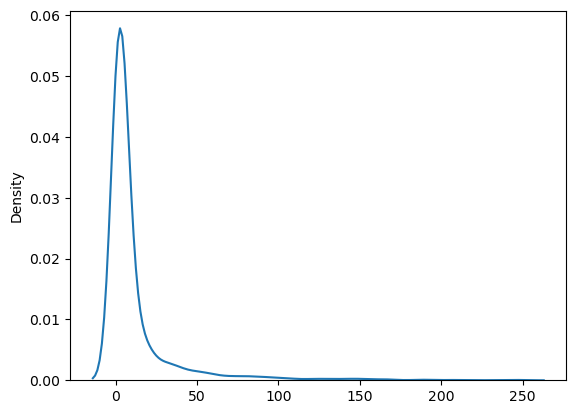

In [ ]:
# Dosť skewed, to smrdí hrozne nejakou binomickou/power law
sns.kdeplot(degree_sequence)
plt.show()